In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature

In [2]:
ds = xr.open_zarr("Simulation_Satellite_kN_0.001.zarr").dropna(dim='obs', how='all')

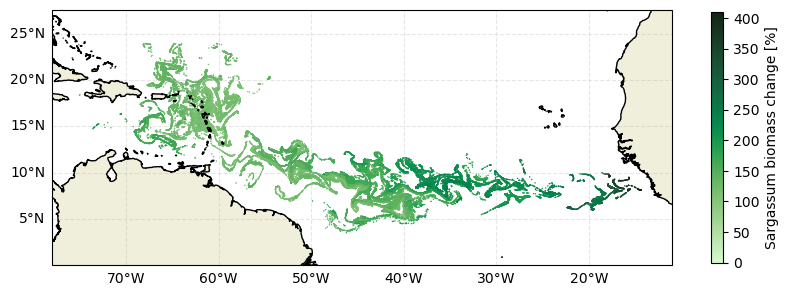

In [3]:
fig = plt.figure(figsize = (10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')

vals = ds.biomass_SF3[:, -1].values * 100
clim = [0, np.nanmax(vals)]

cscat = ax.scatter(ds.lon[:,-1], ds.lat[:,-1], c = vals, clim=clim,
                   cmap=cmo.algae, s=1, linewidth=0, transform=ccrs.PlateCarree(), zorder=1)

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=2)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.set_extent([-78, -11, 0, 24])

#ax.set_extent([-59,-50,3,12])
cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Sargassum biomass change [%]', shrink=0.65)

fig.savefig('Figure5.png', bbox_inches='tight', dpi=300)

plt.show()